### Tweak 2: Regularization — Baseline vs. Dropout

#### 1.1 Environment Check

In [1]:
import random
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import time
import copy

In [2]:
# reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')
if device.type == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4
VRAM            : 15.6 GB


#### 1.2 The Subset

In [3]:
def get_cifar10_subsets(n_train=5000, n_test=1000, batch_size=64, num_workers=2):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616))
    ])

    full_train = torchvision.datasets.CIFAR10(
        root='../data', train=True, download=True, transform=transform)
    full_test = torchvision.datasets.CIFAR10(
        root='../data', train=False, download=True, transform=transform)

    train_indices, _ = train_test_split(list(range(len(full_train))), train_size=n_train, stratify=full_train.targets, random_state=SEED)
    train_subset = Subset(full_train, train_indices)
    test_indices, _ = train_test_split(list(range(len(full_test))), train_size=n_test, stratify=full_test.targets, random_state=SEED)
    test_subset = Subset(full_test, test_indices)

    train_loader = DataLoader(train_subset, batch_size=batch_size,
                              shuffle=True, num_workers=num_workers)
    val_loader   = DataLoader(test_subset,  batch_size=batch_size,
                              shuffle=False, num_workers=num_workers)

    return train_loader, val_loader, full_train.classes

In [4]:
train_loader, val_loader, classes = get_cifar10_subsets()

print(f'Training samples   : {len(train_loader.dataset)}')
print(f'Validation samples : {len(val_loader.dataset)}')
print(f'Classes            : {classes}')
print(f'Batch size         : {train_loader.batch_size}')

100%|██████████| 170M/170M [00:13<00:00, 13.0MB/s] 


Training samples   : 5000
Validation samples : 1000
Classes            : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Batch size         : 64


#### 1.3 Evaluation Suite

In [5]:
def count_parameters(model):
    """Return total number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [6]:
@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    """Compute average loss and accuracy on a dataloader."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

In [7]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                device, epochs=15):
    """
    Standard training loop. Returns history dict with per-epoch metrics.
    """
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [],   'val_acc': []
    }
    best_val_acc = 0.0
    best_weights = None

    for epoch in range(1, epochs + 1):
        # --- train ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc  = 100.0 * correct / total

        # --- validate ---
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        # record
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # checkpoint best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(f'Epoch {epoch:3d}/{epochs}  |  '
              f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%  |  '
              f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%')

    # restore best weights
    if best_weights:
        model.load_state_dict(best_weights)
    print(f'\nBest validation accuracy: {best_val_acc:.2f}%')
    return history

In [8]:
def plot_history(history, title='Training History'):
    """Plot loss and accuracy curves side by side."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- loss ---
    ax1.plot(epochs, history['train_loss'], 'o-', label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   's-', label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} \u2014 Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- accuracy ---
    ax2.plot(epochs, history['train_acc'], 'o-', label='Train Acc')
    ax2.plot(epochs, history['val_acc'],   's-', label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{title} \u2014 Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---
### 2. Model Definitions

#### 2.3 Model C - Dropout

Adds `Dropout2d(0.25)` after each pooling layer and `Dropout(0.5)` before the final FC layer.

In [9]:
class SimpleCNN_Dropout(nn.Module):
    """
    Model C: baseline + Dropout after pooling layers and before final FC.
    """

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
model = SimpleCNN_Dropout().to(device)
print(model)
print(f'\nTrainable parameters: {count_parameters(model):,}')

SimpleCNN_Dropout(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.25, inplace=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Trainable parameters: 268,650


---
#### 3. Train All Three Models

Same hyperparameters for all: **Adam (lr=0.001)** \u00b7 **CrossEntropyLoss** \u00b7 **15 epochs** \u00b7 **batch size 64**

In [11]:
EPOCHS = 15 # complete pass through your entire training dataset
LR = 1e-3   # Learning Rate

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print(f'Optimizer : Adam (lr={LR})')
print(f'Loss fn   : CrossEntropyLoss')
print(f'Epochs    : {EPOCHS}')
print(f'Device    : {device}')
print('-' * 65)

start = time.time()
history = train_model(model, train_loader, val_loader, criterion,
                      optimizer, device, epochs=EPOCHS)
elapsed = time.time() - start
print(f'\nTraining time: {elapsed:.1f}s')

Optimizer : Adam (lr=0.001)
Loss fn   : CrossEntropyLoss
Epochs    : 15
Device    : cuda
-----------------------------------------------------------------
Epoch   1/15  |  Train Loss: 2.1438  Acc: 20.16%  |  Val Loss: 1.8943  Acc: 34.20%
Epoch   2/15  |  Train Loss: 1.9048  Acc: 31.06%  |  Val Loss: 1.6868  Acc: 45.20%
Epoch   3/15  |  Train Loss: 1.7809  Acc: 35.88%  |  Val Loss: 1.5913  Acc: 46.30%
Epoch   4/15  |  Train Loss: 1.6799  Acc: 39.58%  |  Val Loss: 1.5139  Acc: 46.80%
Epoch   5/15  |  Train Loss: 1.6232  Acc: 41.40%  |  Val Loss: 1.4777  Acc: 46.50%
Epoch   6/15  |  Train Loss: 1.5747  Acc: 43.94%  |  Val Loss: 1.4603  Acc: 50.00%
Epoch   7/15  |  Train Loss: 1.5300  Acc: 44.64%  |  Val Loss: 1.4302  Acc: 49.80%
Epoch   8/15  |  Train Loss: 1.4920  Acc: 46.48%  |  Val Loss: 1.4084  Acc: 50.30%
Epoch   9/15  |  Train Loss: 1.4556  Acc: 48.02%  |  Val Loss: 1.3773  Acc: 51.60%
Epoch  10/15  |  Train Loss: 1.4180  Acc: 49.72%  |  Val Loss: 1.3598  Acc: 52.50%
Epoch  11/15  |

---
### 4. Individual Training Curves

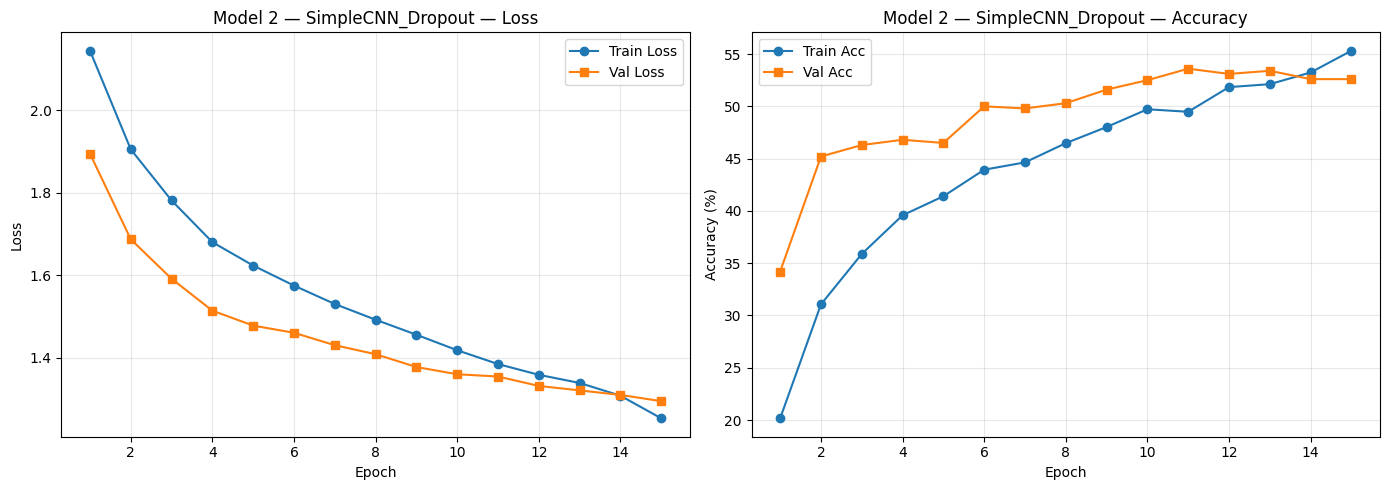

In [12]:
plot_history(history, title='Model 2 — SimpleCNN_Dropout')

---
### 5. Results Summary Table

In [13]:
final_train_acc = history['train_acc'][-1]
final_val_acc   = history['val_acc'][-1]
peak_val_acc    = max(history['val_acc'])
gap             = final_train_acc - final_val_acc

print('=' * 50)
print('         MODEL 2 — RESULTS SUMMARY')
print('=' * 50)
print(f'  Parameters       : {count_parameters(model):,}')
print(f'  Final Train Acc  : {final_train_acc:.2f}%')
print(f'  Final Val Acc    : {final_val_acc:.2f}%')
print(f'  Peak Val Acc     : {peak_val_acc:.2f}%')
print(f'  Train-Val Gap    : {gap:+.2f}%')
print(f'  Final Train Loss : {history["train_loss"][-1]:.4f}')
print(f'  Final Val Loss   : {history["val_loss"][-1]:.4f}')
print(f'  Diagnosis      : Excellent gap control — Dropout eliminates overfitting but the 2-layer architecture caps absolute accuracy (underfitting).')
print('=' * 50)

         MODEL 2 — RESULTS SUMMARY
  Parameters       : 268,650
  Final Train Acc  : 55.32%
  Final Val Acc    : 52.60%
  Peak Val Acc     : 53.60%
  Train-Val Gap    : +2.72%
  Final Train Loss : 1.2530
  Final Val Loss   : 1.2947
  Diagnosis      : Excellent gap control — Dropout eliminates overfitting but the 2-layer architecture caps absolute accuracy (underfitting).
